# Robustness Analysis of the SEIRS-SEI Malaria Model: LHS + PRCC

This notebook performs an **LHS + PRCC** robustness analysis of the SEIRS-SEI malaria
model, complementing the variance-based (Sobol') sensitivity analysis of $\mathcal{R}_0$
(`../sensitivity_analysis/`). Where Sobol' decomposes *variance*, PRCC is a cheap,
rank-based, monotone sensitivity measure that extends naturally to ODE-computed outputs
that are too expensive for 200,000+ function evaluations.

Four analyses are presented:

* **A** — LHS + PRCC of the closed-form $\mathcal{R}_0$;
* **B** — LHS + PRCC of the **seasonal $I_H$ peak** (ODE, averaged over 2017–2023);
* **C** — across-year calibration uncertainty of $b_1,b_2$ propagated to $\mathcal{R}_0$;
* **D** — cross-validation robustness of the week-level regression ($b_1,b_2$ $R^2$): the
  role of the year-to-year level.

A full methodological description and the honest caveats are in `README.md` in this folder.

In [2]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from SALib.sample import latin
from IPython.display import Image, display

import model_wrappers as mw
from lhs_prcc import (
    lhs_sample, prcc_correlations, spearman_correlations, tornado_values,
    prcc_barh, tornado_fig, apply_paper_style,
    GROUP_COLORS, GROUP_LABELS,
)
from run_lhs_prcc import (
    R0_NAMES, ODE_NAMES, eval_r0_rows, eval_ih_peak_rows,
    _prcc_table, BOUNDS,
)
import b1b2_uncertainty as b1b2

apply_paper_style()
plt.rcParams.update({"figure.dpi": 130, "savefig.dpi": 300})
SEED = 42
FIG = os.path.join(os.getcwd(), "figures")
os.makedirs(FIG, exist_ok=True)

def show_and_save(fig, name, dpi=150):
    path = os.path.join(FIG, name)
    if os.path.exists(path):
        os.remove(path)  # WSL/DrvFs: remove before overwrite avoids Errno 22
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=path))

print("Setup complete.")

Climate data 2017-2023: 2556 days
Cases data 2017-2023: 2556 rows
lmfit version: 1.3.2

2017 direct start (no warm-up): N=8369, M'=334760 (40.00 x N)
Initial human compartments in 2017: N=8369, S_H=5752, E_H=418, I_H=944, R_H=1255
Initial mosquito compartments in 2017: M=83690, S_M=76994, E_M=5022, I_M=1674
Setup complete.


## 0. Reference parameters

The Sobol' analysis evaluates $\mathcal{R}_0$ at a fixed *reference* combination. For this
robustness study we deliberately use the **calibrated per-year means** of the
epidemiological parameters (from `lmfit_results.json`) together with the Sobol'-analysis
baseline for the climate-response parameters. Using fitted values rather than parameter
midpoints matters: the $\gamma$ midpoint (~0.5/day, a 2-day recovery) pins the ODE
$I_H$ peak at an artificial ceiling, so calibrated means are the correct "other
parameters held fixed" baseline.

In [4]:
ref_r0 = mw.reference_params(R0_NAMES)
print("Calibrated reference (means across 2017-2023):")
for k in R0_NAMES:
    print(f"  {k:8s} = {ref_r0[k]:.4g}")
print(f"\\nR0 at reference climate = {eval_r0_rows(np.array([[ref_r0[n] for n in R0_NAMES]]), R0_NAMES)[0]:.3f}")

Calibrated reference (means across 2017-2023):
  H0       = 22.91
  k        = 0.1625
  phi      = 0.4451
  gamma    = 0.007589
  b1       = 0.4598
  b2       = 0.02085
  M_prime  = 5.099e+04
  T_prime  = 16
  D1       = 24.8
  R_L      = 32.67
  DD       = 105
  Tmin     = 14.5
  Tmax_plasm = 29.5
  Topt_plasm = 23.5
  A        = -0.03
  B        = 1.31
  C        = -4.4
  B_E      = 200
  c1       = 0.00554
  c2       = -0.06737
  Tmin_anop = 16
  Topt_anop = 25
  Tmax_anop = 34
\nR0 at reference climate = 1.327


## A. LHS + PRCC of the closed-form $\mathcal{R}_0$

We draw $n$ Latin-hypercube rows over the same 25-dimensional hypercube (and ranges) as
the Sobol' analysis, evaluate the analytical $\mathcal{R}_0$ for each, and rank both the
inputs and the output before computing partial correlations (PRCC).

In [6]:
X = lhs_sample(R0_NAMES, n_samples=800, seed=SEED)
Y = eval_r0_rows(X, R0_NAMES)
df_r0 = _prcc_table(X, Y, R0_NAMES, None)
print(f"Evaluated {len(Y)} values of R0  (min {Y.min():.2f}, median {np.median(Y):.2f}, "
      f"max {Y.max():.2f})")
df_r0.head(25).round(3)

Evaluated 800 values of R0  (min 0.00, median 0.77, max 49.41)


,parameter,group,lower,upper,PRCC,p_value,n_used,spearman
14,A,climate_mortality,-0.050,-0.010,0.815,0.000,800,0.657
15,B,climate_mortality,1.000,1.600,0.615,0.000,800,0.350
3,gamma,calibrated_epi,0.007,1.000,-0.365,0.000,800,-0.200
4,b1,calibrated_epi,0.001,0.500,0.356,0.000,800,0.197
6,M_prime,calibrated_epi,50000.000,4184500.000,0.341,0.000,800,0.235
5,b2,calibrated_epi,0.010,0.500,0.324,0.000,800,0.130
1,k,calibrated_epi,0.010,1.000,0.285,0.000,800,0.165
9,R_L,climate_rate,20.000,50.000,-0.193,0.000,800,-0.098
0,H0,calibrated_epi,20.000,75.000,-0.180,0.000,800,-0.111
10,DD,climate_rate,80.000,140.000,-0.165,0.000,800,-0.099


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


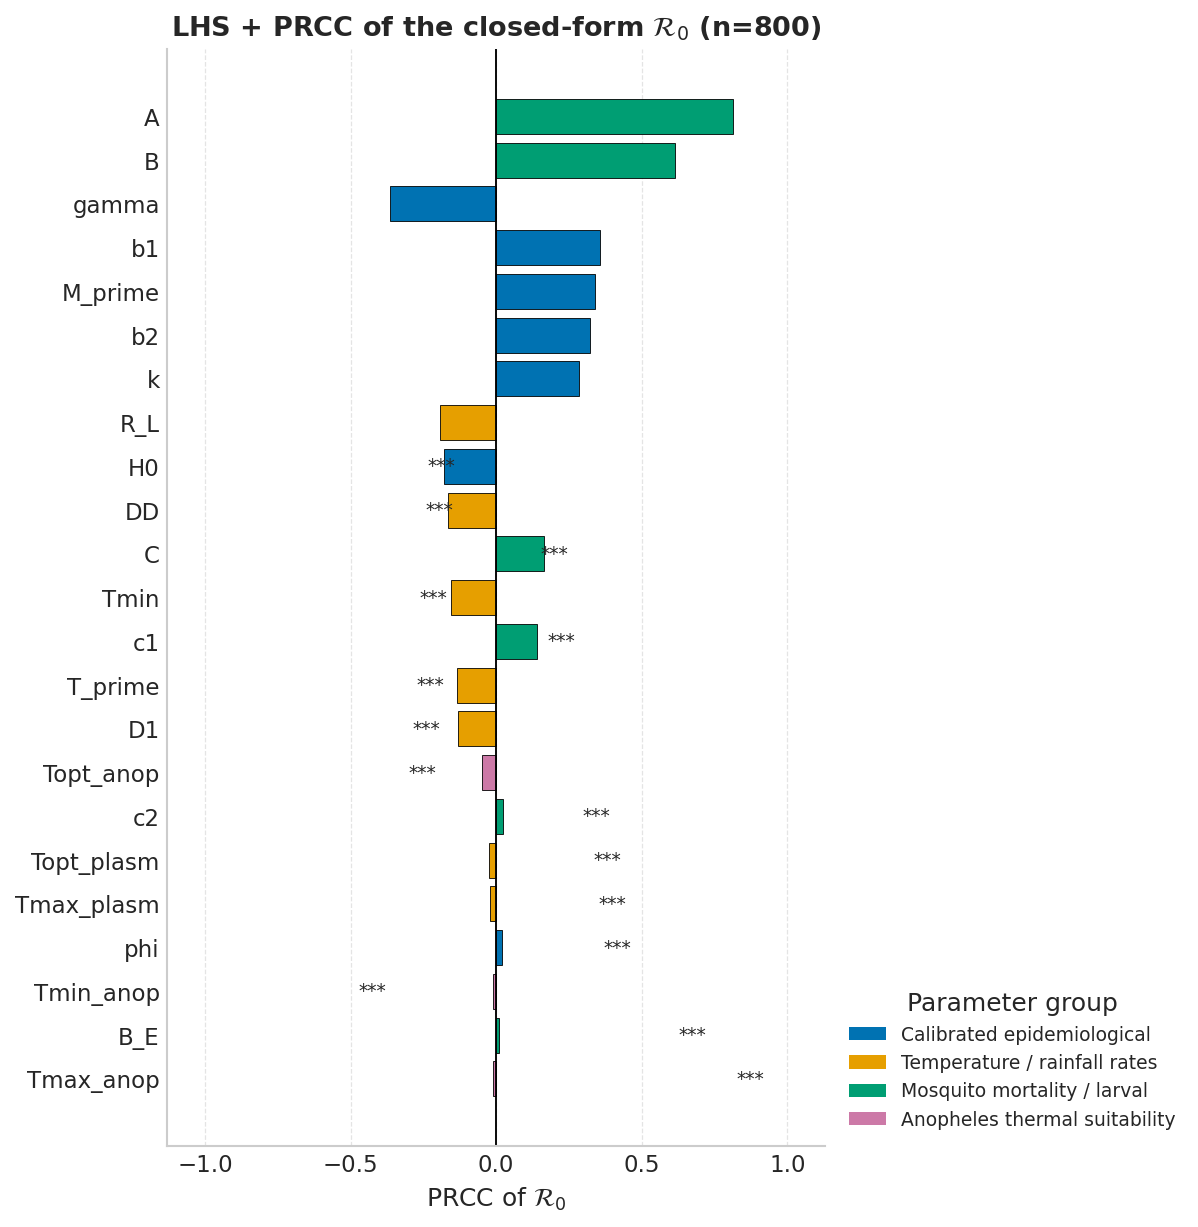

In [7]:
fig, _ = prcc_barh(df_r0, "PRCC of $\\mathcal{R}_0$",
                      "LHS + PRCC of the closed-form $\\mathcal{R}_0$ (n=800)")
show_and_save(fig, "prcc_r0_barh.png")

### One-at-a-time tornado at the calibrated reference

Showing the swing in $\mathcal{R}_0$ observed as each parameter is moved to its lower and
upper bound while the others sit at the calibrated reference.

In [9]:
tor, base_out = tornado_values(eval_r0_rows, R0_NAMES, baseline=ref_r0)
print(f"Base R0 (calibrated reference) = {base_out:.3f}")
tor.head(12).round(3)

Base R0 (calibrated reference) = 1.327


,parameter,group,lower,upper,low_out,high_out,swing
6,M_prime,calibrated_epi,50000.000,4184500.00,1.314,12.022,10.708
5,b2,calibrated_epi,0.010,0.50,0.919,6.498,5.579
14,A,climate_mortality,-0.050,-0.01,0.000,3.283,3.283
15,B,climate_mortality,1.000,1.60,0.015,2.540,2.525
4,b1,calibrated_epi,0.001,0.50,0.062,1.384,1.322
3,gamma,calibrated_epi,0.007,1.00,0.116,1.416,1.300
0,H0,calibrated_epi,20.000,75.00,0.143,1.327,1.185
1,k,calibrated_epi,0.010,1.00,0.145,1.328,1.183
7,T_prime,climate_rate,14.000,20.00,0.772,1.604,0.832
8,D1,climate_rate,18.000,32.00,1.028,1.828,0.800


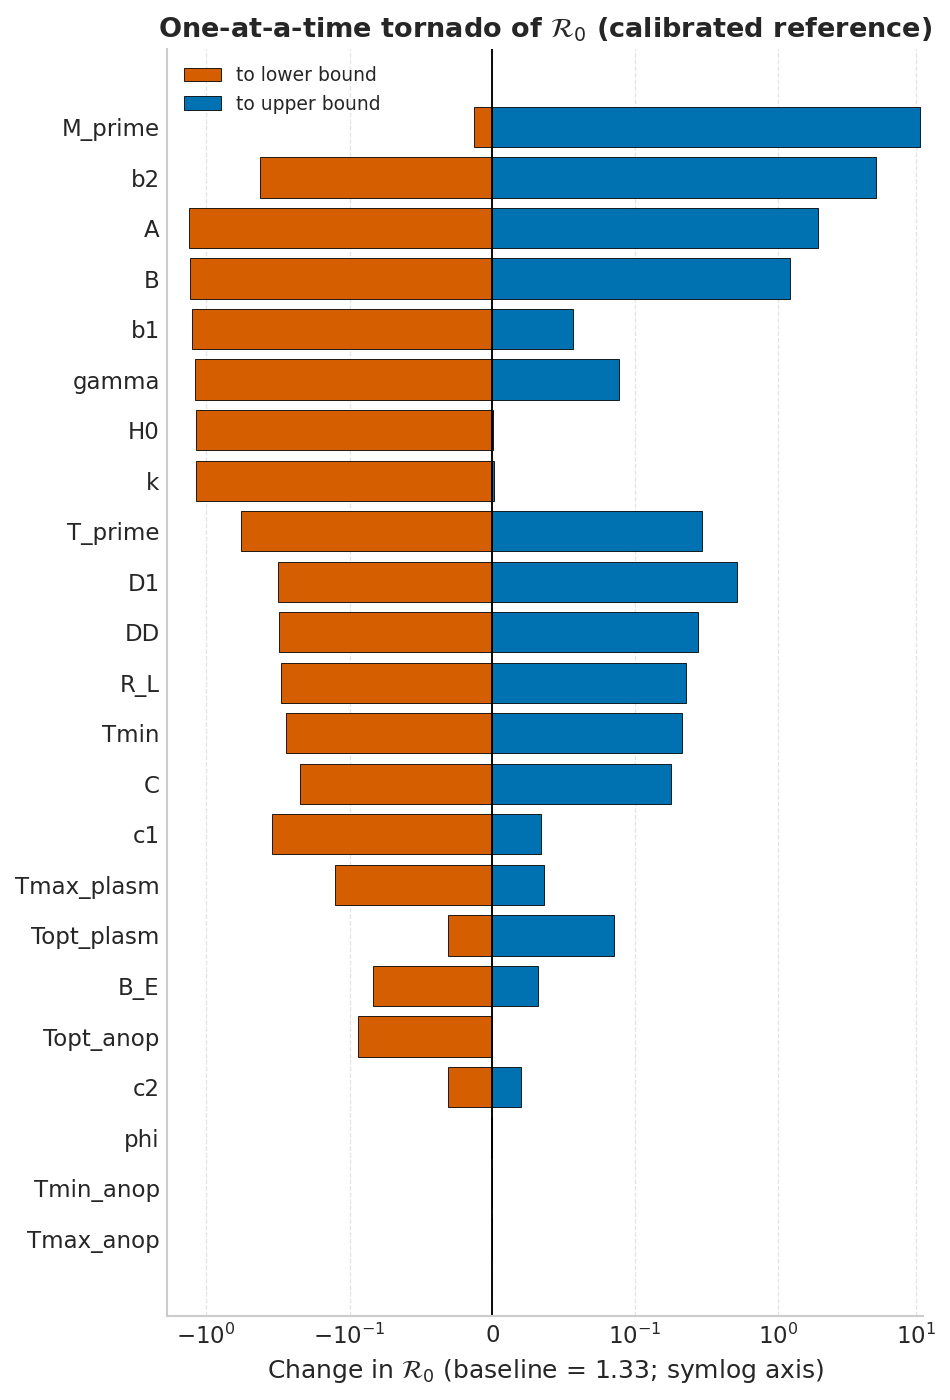

In [10]:
fig, _ = tornado_fig(tor, base_out, use_symlog=True,
                        title="One-at-a-time tornado of $\\mathcal{R}_0$ "
                              "(calibrated reference)",
                        value_label="Change in $\\mathcal{R}_0$")
show_and_save(fig, "r0_tornado.png")

## B. LHS + PRCC of the seasonal $I_H$ peak (ODE)

Each LHS row drives **seven ODE year-simulations** (2017–2023) and we record the mean of
the daily human-infectious peak. Because the peak is near-instant to reach in each year, a
modest sample is used.

> **Heavy cell, runtime warning**: the default below uses $n=150$ (~2–3 min). The paper
> figures use $n=400$ (shipped in `figures/` and `tables/`). Set `IH_N = 400` and re-run if
> you want the full sample.

In [12]:
IH_N = 150
Xih = lhs_sample(ODE_NAMES, n_samples=IH_N, seed=SEED)
Yih = eval_ih_peak_rows(Xih, ODE_NAMES)
print("Evaluated mean seasonal I_H peak for", len(Yih), "parameter rows. "
      f"(n_valid={int(np.isfinite(Yih).sum())})")

Evaluated mean seasonal I_H peak for 150 parameter rows. (n_valid=150)


The $I_H$ peak is heavily right-skewed (a plateau near the calibrated value ~917 with
extreme excursions when $\gamma$ is tiny). PRCC is therefore computed on
$\log_{10}(\text{peak } I_H)$; the raw distribution is shown alongside.

In [14]:
Ylog = np.log10(np.maximum(Yih, 1e-6))
df_ih = _prcc_table(Xih, Ylog, ODE_NAMES, None)
df_ih.head(15).round(3)

,parameter,group,lower,upper,PRCC,p_value,n_used,spearman
4,gamma,calibrated_epi,0.007,1.00,-0.656,0.000,150,-0.555
16,A,climate_mortality,-0.050,-0.01,0.528,0.000,150,0.388
6,b1,calibrated_epi,0.001,0.50,0.334,0.000,150,0.225
17,B,climate_mortality,1.000,1.60,0.289,0.001,150,0.224
23,Topt_anop,anop_suitability,22.000,28.00,-0.216,0.015,150,-0.133
7,b2,calibrated_epi,0.010,0.50,0.184,0.040,150,0.134
15,Topt_plasm,climate_rate,21.000,26.00,0.174,0.051,150,0.121
13,Tmin,climate_rate,12.000,17.00,-0.164,0.066,150,-0.092
1,k,calibrated_epi,0.010,1.00,0.158,0.077,150,0.056
10,D1,climate_rate,18.000,32.00,-0.142,0.114,150,-0.043


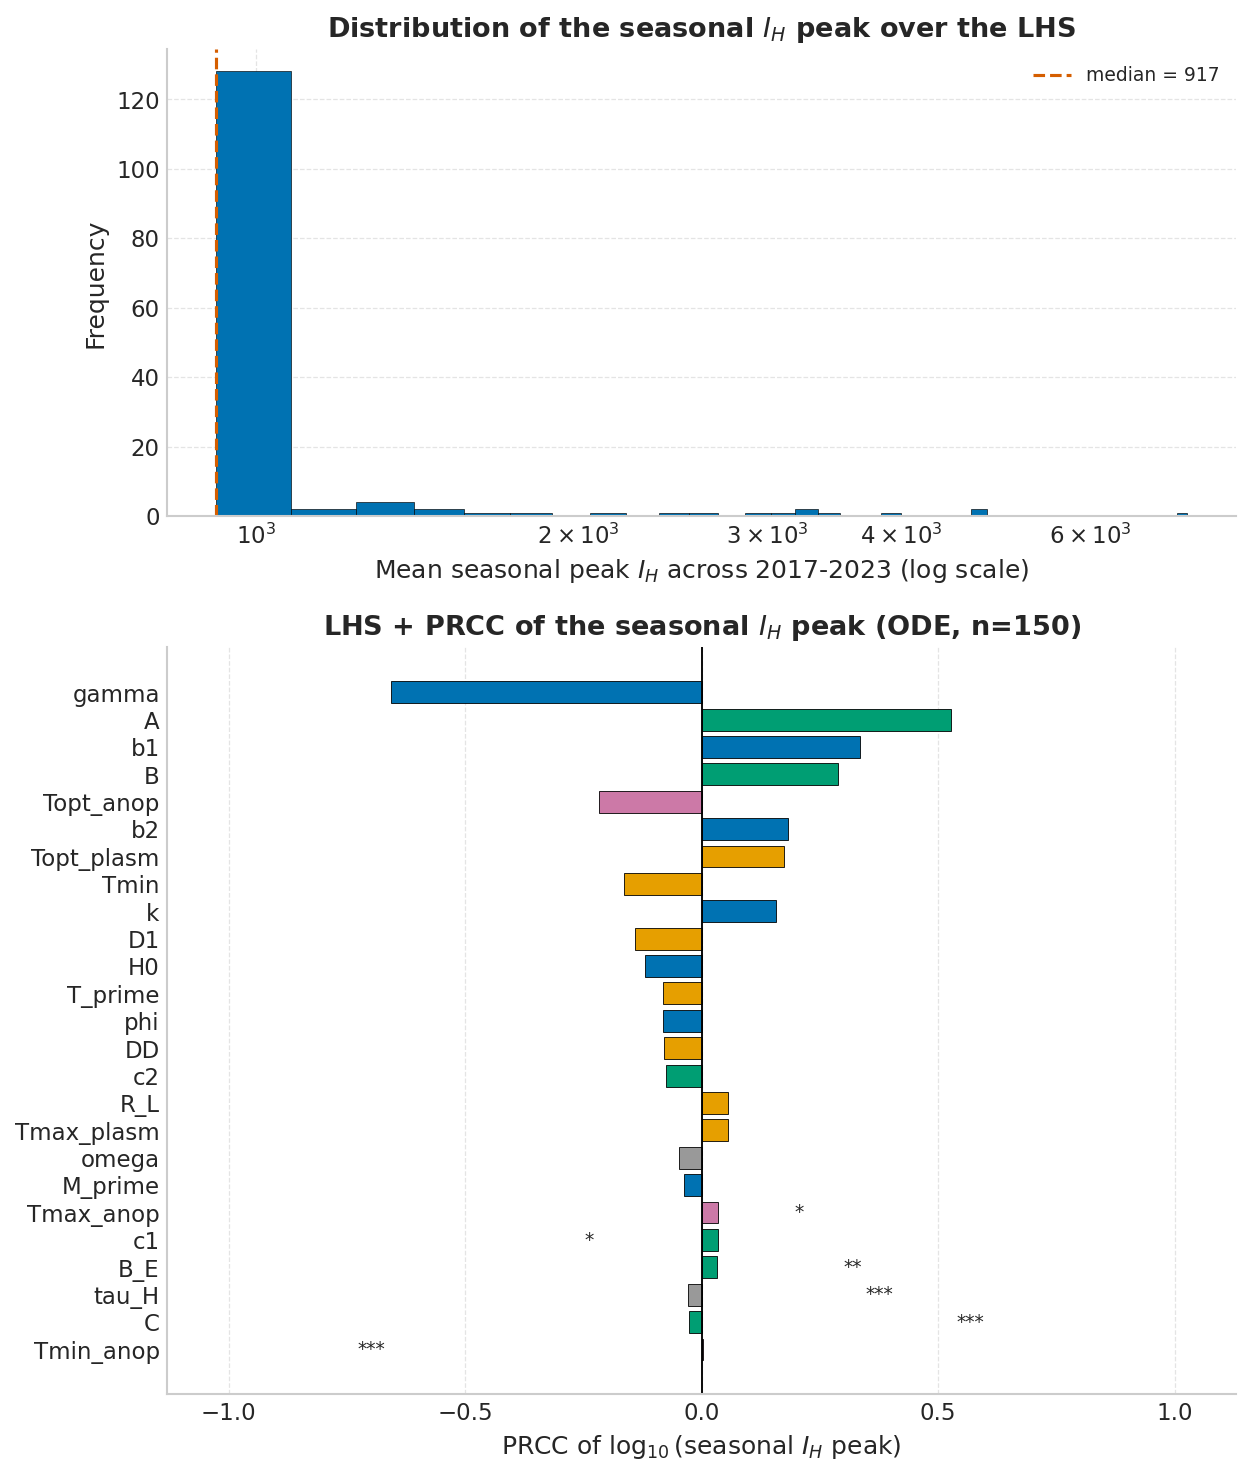

In [15]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(8.5, 10),
                                   gridspec_kw={"height_ratios": [1, 1.6]})
hit = np.isfinite(Yih)
a1.hist(Yih[hit], bins=40, color="#0072B2", edgecolor="black", linewidth=0.3)
a1.set_xscale("log")
a1.axvline(np.median(Yih[hit]), color="#D55E00", ls="--",
           label=f"median = {np.median(Yih[hit]):.0f}")
a1.set_xlabel("Mean seasonal peak $I_H$ across 2017-2023 (log scale)")
a1.set_ylabel("Frequency")
a1.set_title("Distribution of the seasonal $I_H$ peak over the LHS")
a1.legend(frameon=False, fontsize=9)
prcc_barh(df_ih, "PRCC of $\\log_{10}$(seasonal $I_H$ peak)",
          "LHS + PRCC of the seasonal $I_H$ peak (ODE, n=%d)" % IH_N,
          ax=a2, legend=False)
plt.tight_layout(); show_and_save(fig, "prcc_ih_peak_combined.png")

## C. Across-year calibration uncertainty of $b_1,b_2$ → $\mathcal{R}_0$

The week-level fits produce a *different* $b_1,b_2$ for every year. We report that drift
toward the fit bounds and propagate each year's calibrated vector to $\mathcal{R}_0$.

In [17]:
yrs = b1b2.across_year_b1b2_table()
summ = b1b2.uncertainty_summary(yrs)
corr = b1b2.b1b2_correlation(yrs)
print("Per-year calibrated b1, b2 and resulting R0 at the reference climate:")
yrs[["year", "b1", "b2", "R0"]].round(3)

Per-year calibrated b1, b2 and resulting R0 at the reference climate:


,year,b1,b2,R0
0,2017,0.259,0.035,1.333
1,2018,0.487,0.022,0.961
2,2019,0.488,0.022,1.052
3,2020,0.500,0.019,0.814
4,2021,0.500,0.019,0.890
5,2022,0.500,0.019,0.741
6,2023,0.485,0.010,0.947


In [18]:
print("Across-year uncertainty summary (CV%):")
print(summ.round(1))
print("\\nCorrelation of per-year b1 vs b2:")
print(f"  Pearson r = {corr['pearson_r']:.3f} (p={corr['pearson_p']:.3f})")
print(f"  Spearman rho = {corr['spearman_rho']:.3f} (p={corr['spearman_p']:.3f})")

Across-year uncertainty summary (CV%):
                  mean   sd  min  max  cv_pct
b1 (mosq->human)   0.5  0.1  0.3  0.5    19.3
b2 (human->mosq)   0.0  0.0  0.0  0.0    35.3
R0                 1.0  0.2  0.7  1.3    20.0
\nCorrelation of per-year b1 vs b2:
  Pearson r = -0.832 (p=0.020)
  Spearman rho = -0.455 (p=0.306)


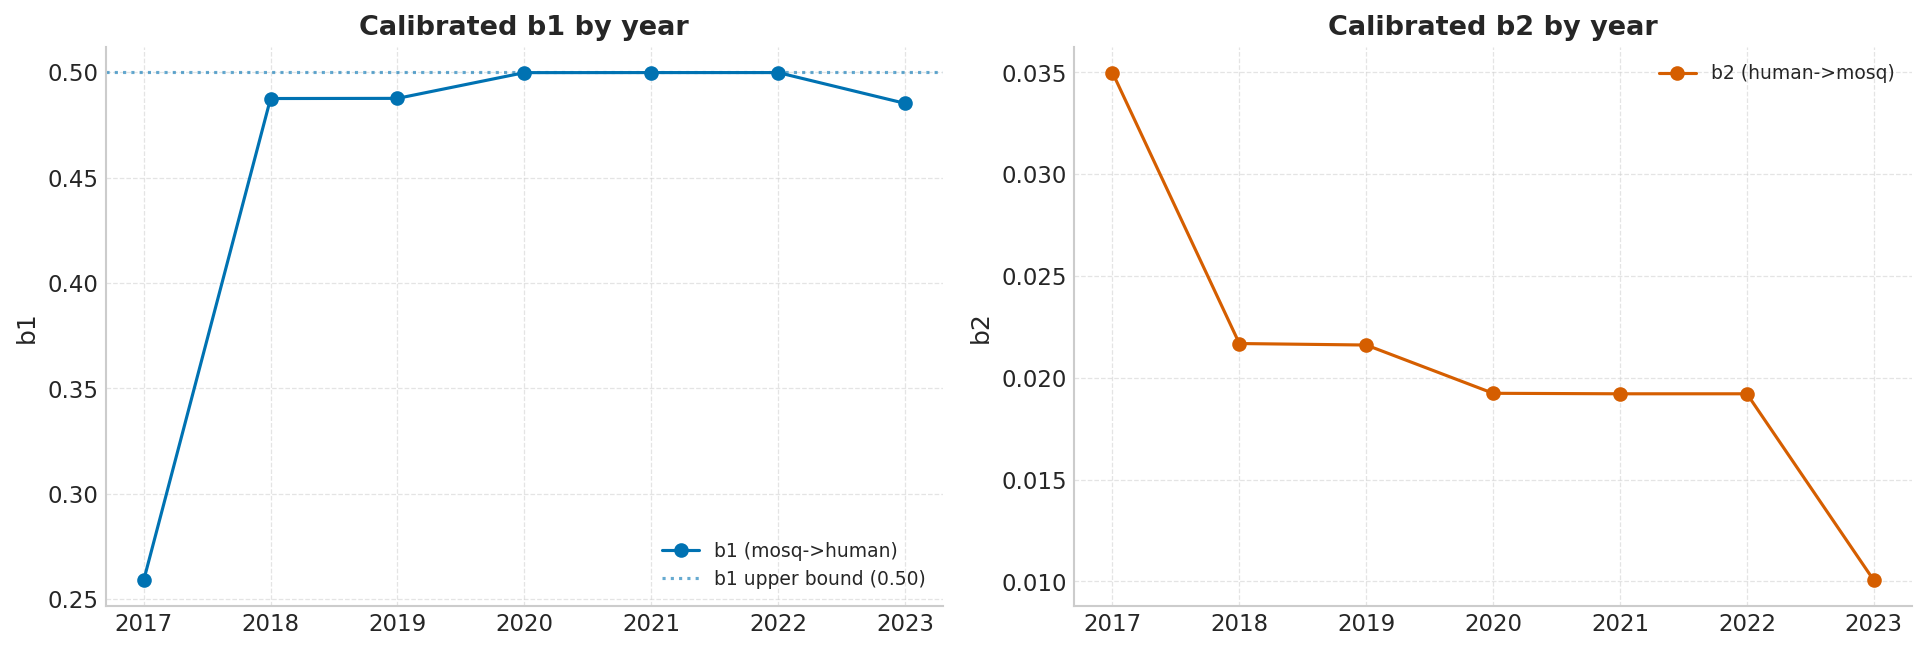

In [19]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
x = yrs["year"].values
a1.plot(x, yrs["b1"], "-o", color="#0072B2", label="b1 (mosq->human)")
a1.axhline(0.5, color="#0072B2", ls=":", alpha=0.6, label="b1 upper bound (0.50)")
a1.set_ylabel("b1"); a1.set_xticks(x); a1.legend(fontsize=9, frameon=False); a1.set_title("Calibrated b1 by year")
a2.plot(x, yrs["b2"], "-o", color="#D55E00", label="b2 (human->mosq)")
a2.set_ylabel("b2"); a2.set_xticks(x); a2.legend(fontsize=9, frameon=False); a2.set_title("Calibrated b2 by year")
plt.tight_layout(); show_and_save(fig, "b1b2_by_year.png")

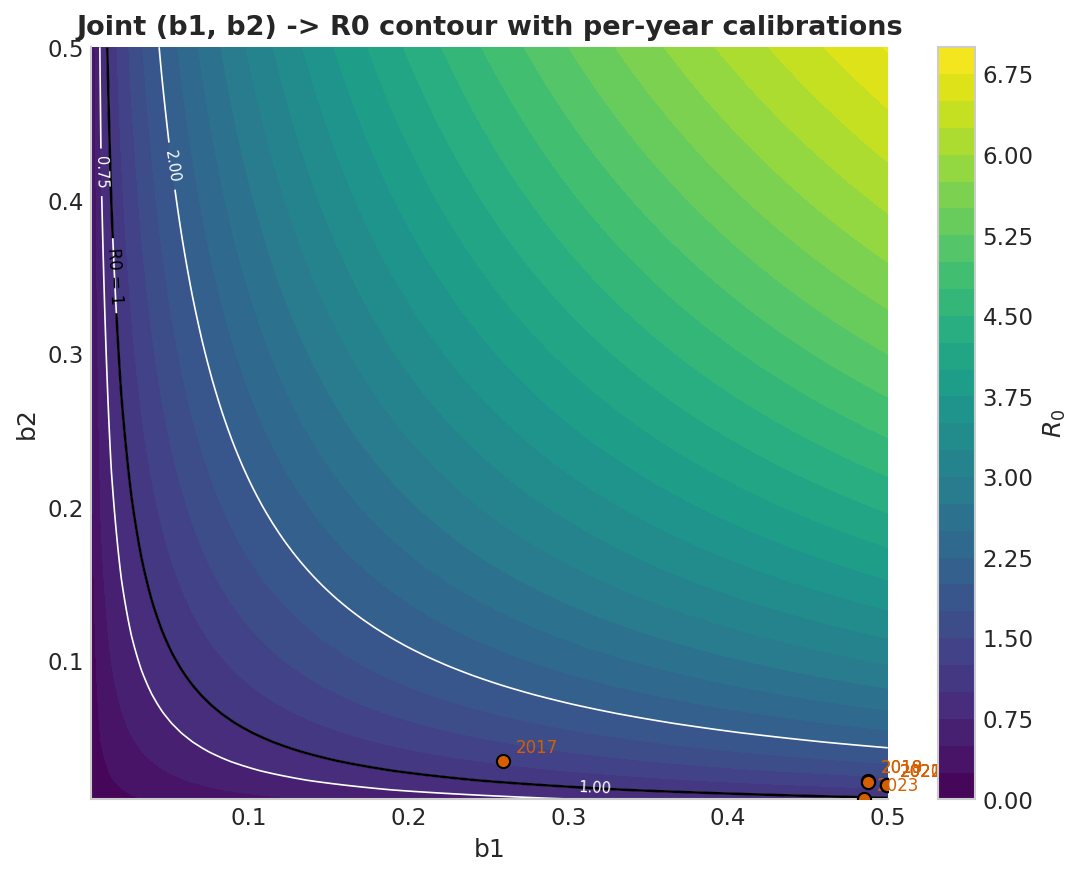

In [20]:
fig, ax = plt.subplots(figsize=(7.5, 6))
base = mw.reference_params(R0_NAMES)
b1g = np.linspace(BOUNDS["b1"][0], BOUNDS["b1"][1], 80)
b2g = np.linspace(BOUNDS["b2"][0], BOUNDS["b2"][1], 80)
B1, B2 = np.meshgrid(b1g, b2g)
R0g = np.empty_like(B1)
for i in range(len(b2g)):
    for j in range(len(b1g)):
        row = [base[n] if n not in ("b1", "b2") else (B1[i, j] if n == "b1" else B2[i, j]) for n in R0_NAMES]
        R0g[i, j] = eval_r0_rows(np.array([row]), R0_NAMES)[0]
cf = ax.contourf(B1, B2, R0g, levels=30, cmap="viridis")
cs = ax.contour(B1, B2, R0g, levels=[0.75, 1, 2], colors="white", linewidths=0.8)
ax.clabel(cs, inline=True, fontsize=7, fmt="%.2f")
cs1 = ax.contour(B1, B2, R0g, levels=[1], colors="black", linewidths=1.2)
ax.clabel(cs1, inline=True, fontsize=8, fmt="R0 = 1")
ax.scatter(yrs["b1"], yrs["b2"], color="#D55E00", s=40, zorder=5, edgecolor="black")
for _, r in yrs.iterrows():
    ax.annotate(int(r["year"]), (r["b1"], r["b2"]), textcoords="offset points", xytext=(6, 4), fontsize=8, color="#D55E00")
ax.set_xlabel("b1"); ax.set_ylabel("b2")
ax.set_title("Joint (b1, b2) -> R0 contour with per-year calibrations")
cb = fig.colorbar(cf, ax=ax); cb.set_label("$R_0$")
plt.tight_layout(); show_and_save(fig, "b1b2_r0_contour.png")

## E. Yearly $\mathcal{R}_0$, 2017–2023: crossing the $\mathcal{R}_0 = 1$ threshold

The closed-form $\mathcal{R}_0$ (`seirs_sei_r0.r0_components`) evaluated **day-by-day**
on the Manaus climate record with each year's *calibrated* transmission parameters
$(b_1, b_2, \gamma, M', H_0, k, \phi)$, using the same environmental response functions
as `../../seirs_sei/R0_Calculation.ipynb`. As in the calibrated ODE
(`SMOOTH_WINDOW = 14`), the series is evaluated on the 14-day trailing mean of daily
temperature / rainfall / humidity, so the marked crossings identify the
transmission-season **onset** (up) and **offset** (down) around the $\mathcal{R}_0 = 1$
epidemic threshold rather than day-to-day rainfall noise. The raw daily series is
shown faintly behind the smoothed curve, and the per-year season statistics (days with
$\mathcal{R}_0 > 1$, crossing dates) are printed below.

wrote C:\Users\rapha\Study_on_malaria_dynamics_v2\models\results\lhs_prcc_analysis\figures\r0_yearly.png

Per-year summary (smoothed-14d R0):
 year  r0_min_smoothed  r0_mean_smoothed  r0_max_smoothed  days_r0_above_1_smoothed  frac_days_r0_above_1_smoothed  n_crossings_smooth first_up_crossing_smooth last_down_crossing_smooth
 2017            0.009             0.843            1.511                       156                          0.427                  12               2017-02-26                2017-12-14
 2018            0.014             0.483            1.011                         1                          0.003                   2               2018-04-02                2018-04-03
 2019            0.014             0.603            1.215                        51                          0.140                   7               2019-04-08                2019-06-01
 2020            0.000             0.418            1.078                        11                          0.030

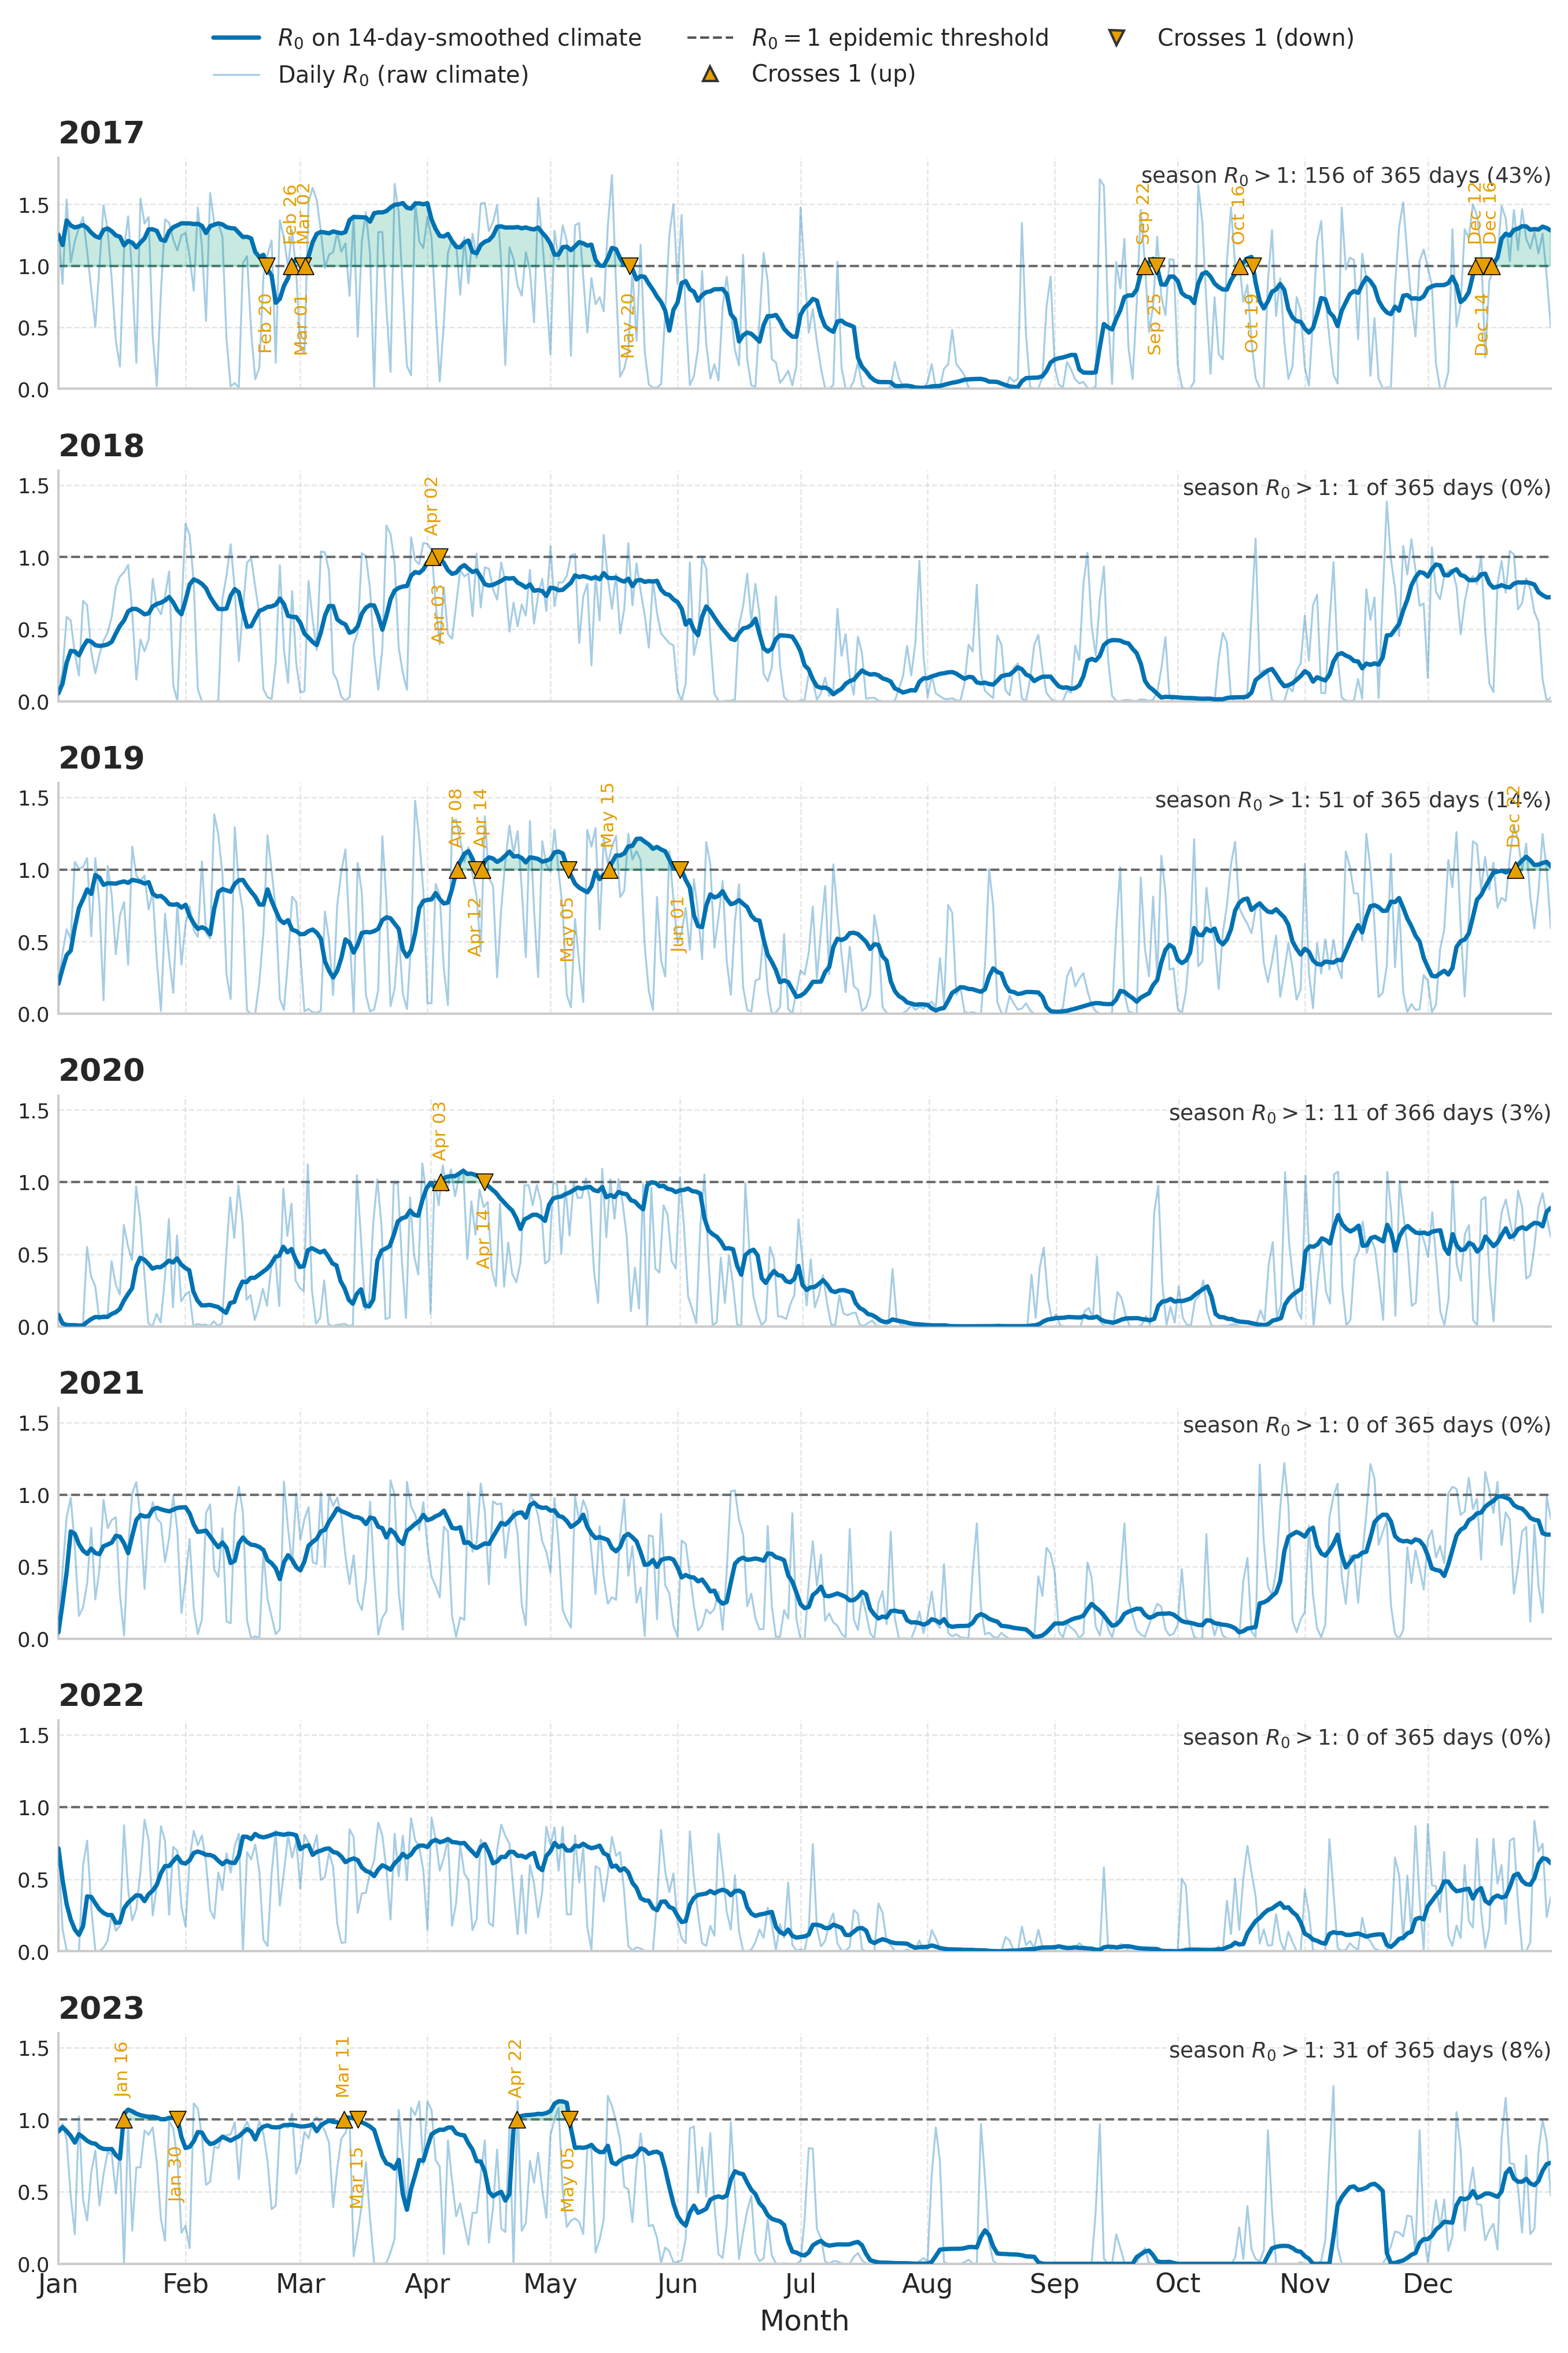

In [22]:
import r0_yearly
r0_yearly.run()
from IPython.display import Image, display
display(Image(filename=os.path.join(r0_yearly.FIG_DIR, "r0_yearly.png")))

## D. Cross-validation robustness: role of the year-to-year level

The diagnostics question is: does the gap between the high **within-year** $R^2$ and the
low **leave-one-year-out (LOYO)** $R^2$ come from the year-to-year *level* of
$b_1,b_2$? We test this by standardizing the target within each year (removing the year
mean/std) and re-measuring both quantities.

> **Honest caveat.** Within-year standardization is a *diagnostic*, not a deployable
> estimator (a held-out year's mean/std cannot be used without target leakage). It is a
> controlled experiment holding the year level fixed.

In [24]:
import cv_robustness as cvr
res_b1 = cvr.run_robustness(cvr.TARGET_B1, verbose=False)
res_b2 = cvr.run_robustness(cvr.TARGET_B2, verbose=False)
pd.DataFrame([res_b1["summary"], res_b2["summary"]])[["target", "within_year_r2_raw",
    "within_year_r2_std", "loyo_overall_r2_raw", "loyo_overall_r2_std",
    "gap_raw", "gap_std", "gap_narrowed"]].round(3)

,target,within_year_r2_raw,within_year_r2_std,loyo_overall_r2_raw,loyo_overall_r2_std,gap_raw,gap_std,gap_narrowed
0,b1_eff,0.496,0.496,0.167,0.214,0.329,0.281,0.047
1,b2_eff,0.634,0.638,0.191,0.439,0.443,0.199,0.245


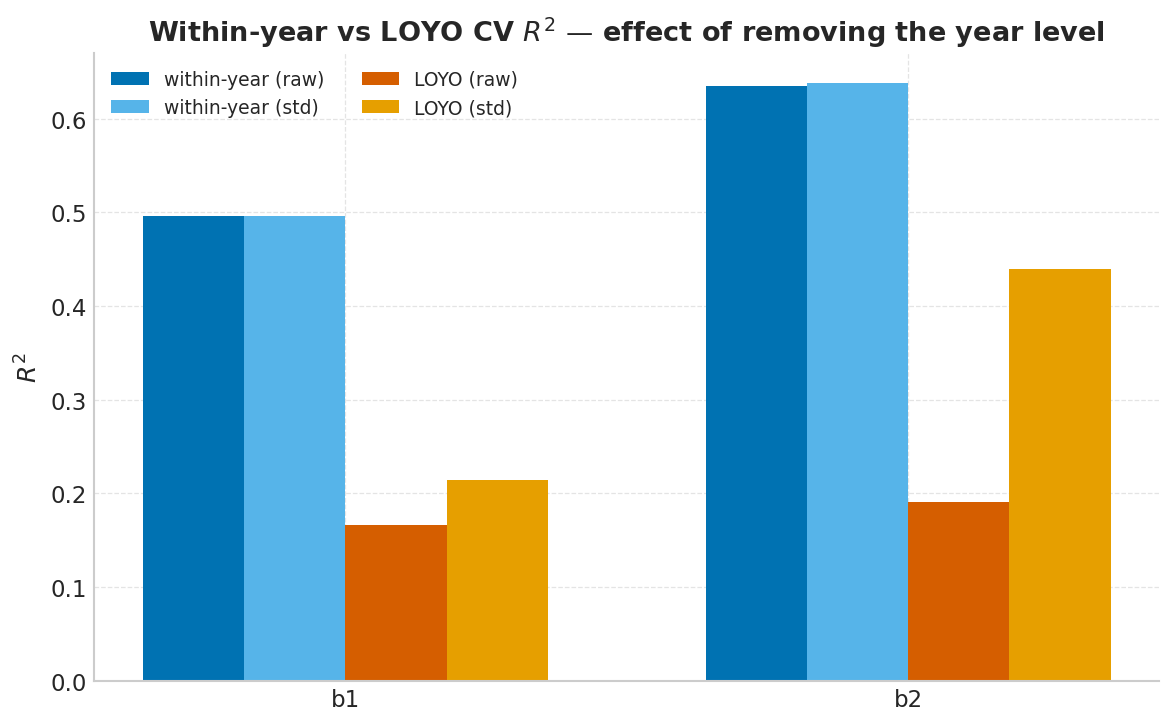

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
labels = ["b1", "b2"]
pos = np.arange(2); w = 0.18
wy_raw = [res_b1["summary"]["within_year_r2_raw"], res_b2["summary"]["within_year_r2_raw"]]
loyo_raw = [res_b1["summary"]["loyo_overall_r2_raw"], res_b2["summary"]["loyo_overall_r2_raw"]]
wy_std = [res_b1["summary"]["within_year_r2_std"], res_b2["summary"]["within_year_r2_std"]]
loyo_std = [res_b1["summary"]["loyo_overall_r2_std"], res_b2["summary"]["loyo_overall_r2_std"]]
ax.bar(pos - 1.5*w, wy_raw, w, label="within-year (raw)", color="#0072B2")
ax.bar(pos - 0.5*w, wy_std, w, label="within-year (std)", color="#56B4E9")
ax.bar(pos + 0.5*w, loyo_raw, w, label="LOYO (raw)", color="#D55E00")
ax.bar(pos + 1.5*w, loyo_std, w, label="LOYO (std)", color="#E69F00")
ax.set_xticks(pos, labels); ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("$R^2$"); ax.set_title("Within-year vs LOYO CV $R^2$ — effect of removing the year level")
ax.legend(fontsize=9, frameon=False, ncol=2); plt.tight_layout(); show_and_save(fig, "cv_robustness.png")

## Discussion for the paper

1. **$R_0$ (closed form).** In agreement with the Sobol' analysis, the uncertainty of
   $\mathcal{R}_0$ is dominated by the mosquito-mortality shape coefficients $A$ and $B$
   and the recovery rate $\gamma$, with transmission probabilities ($b_1,b_2$) and the
   carrying-capacity scale $M'$ secondary, and $\tau_H,\omega$ negligible.

2. **Seasonal $I_H$ peak (ODE).** The epidemic peak is governed chiefly by $\gamma$
   (faster recovery ⇒ smaller peak) and mosquito mortality, then the transmission
   probabilities. The peak output *sits on a plateau* for much of the parameter space
   (median = min), responding only when $\gamma$ is small or transmission/mortality terms
   push it off — a structural property worth stating explicitly.

3. **Calibration uncertainty.** $b_1$ drifts to its upper bound (~0.50) while $b_2$ falls
   toward ~0.01, and the two trade off against each other (Pearson $r=-0.83$). Propagated
   to $\mathcal{R}_0$ at the reference climate, the calibrated vectors give
   $\mathcal{R}_0\in[0.74,\,1.33]$ — near or under the epidemic threshold — in contrast to
   the paper's reference $\mathcal{R}_0=2.20$. The $b_1/b_2$ calibration therefore
   materially modulates endemicity and is a substantive source of model uncertainty.

4. **CV robustness.** Removing the year level raises LOYO $R^2$ for both targets but by
   very different amounts: little for $b_1$ (0.17→0.21; the gap is mostly within-year
   shape misfit) versus strongly for $b_2$ (0.19→0.44; much of the gap is the year-to-year
   level shift).